In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  
from scipy.stats import spearmanr
from matplotlib.colors import LinearSegmentedColormap
from tqdm import tqdm

In [7]:
pred_ptr_df = pd.read_csv('data/ptr_pred_Table_EV6.tsv', sep='\t')
pred_ptr_df

,EnsemblGeneID,tissue,PTR,predicted_PTR
0,ENSG00000175899,Adrenal,6.2900,4.969057
1,ENSG00000128274,Adrenal,3.8430,4.485976
2,ENSG00000094914,Adrenal,4.5130,4.741719
3,ENSG00000081760,Adrenal,4.5590,5.118440
4,ENSG00000114771,Adrenal,5.1100,4.946086
...,...,...,...,...
232914,ENSG00000086827,Urinarybladder,5.1595,4.628090
232915,ENSG00000162378,Urinarybladder,4.1460,4.725523
232916,ENSG00000159840,Urinarybladder,5.3358,4.804666
232917,ENSG00000074755,Urinarybladder,5.0619,4.516096


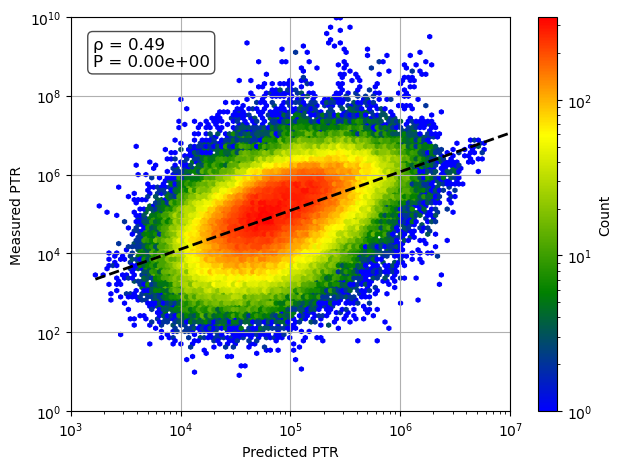

In [6]:
def hexbin(pred_ptr_df):

    ptr = pred_ptr_df['PTR']
    ptr_pred = pred_ptr_df['predicted_PTR']
    rho, pval = spearmanr(ptr_pred, ptr)

    pred_exp = 10**ptr_pred
    
    ptr_exp = 10**ptr

    colors = [
        (0.0, "blue"),
        (0.3, "green"),
        (0.7, "yellow"),
        (1  , "red"),
    ]

    custom_cmap = LinearSegmentedColormap.from_list("blue_yellow_red", colors)

    hb =plt.hexbin(pred_exp, ptr_exp,gridsize=100, 
            xscale = 'log',yscale = 'log',cmap=custom_cmap, bins = 'log' ,mincnt=1  )

    


    m, b = np.polyfit(ptr_pred, ptr, 1)
    x_fit = np.linspace(ptr_pred.min(), ptr.max(), 100)
    y_fit = m * x_fit + b
    
    cb = plt.colorbar(hb)
    cb.set_label('Count')
    plt.plot(10**x_fit, 10**y_fit, color='black', linestyle='--', linewidth=2, label='Fit line')
    plt.xlim(1e3, 1e7)
    plt.ylim(1, 1e10)
    plt.text(
        0.05, 0.95, f'ρ = {float(rho):.2f}\nP = {float(pval):.2e}',
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )
    plt.xlabel('Predicted PTR')
    plt.ylabel('Measured PTR')
    plt.grid()
    plt.tight_layout()
    plt.show()

hexbin(pred_ptr_df)